<a href="https://colab.research.google.com/github/Anuska111/House_Price_Prediction_Local/blob/main/Copy_of_Untitled3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from ipywidgets import Dropdown, FloatSlider, IntSlider, interact
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error
from sklearn.pipeline import make_pipeline



In [ ]:
df=pd.read_csv("/content/Bengaluru_House_Data.csv")
df.head()


,area_type,availability,location,size,society,total_sqft,bath,balcony,price
0,Super built-up Area,19-Dec,Electronic City Phase II,2 BHK,Coomee,1056,2.0,1.0,39.07
1,Plot Area,Ready To Move,Chikka Tirupathi,4 Bedroom,Theanmp,2600,5.0,3.0,120.00
2,Built-up Area,Ready To Move,Uttarahalli,3 BHK,NaN,1440,2.0,3.0,62.00
3,Super built-up Area,Ready To Move,Lingadheeranahalli,3 BHK,Soiewre,1521,3.0,1.0,95.00
4,Super built-up Area,Ready To Move,Kothanur,2 BHK,NaN,1200,2.0,1.0,51.00


In [ ]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13320 entries, 0 to 13319
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   area_type     13320 non-null  object 
 1   availability  13320 non-null  object 
 2   location      13319 non-null  object 
 3   size          13304 non-null  object 
 4   society       7818 non-null   object 
 5   total_sqft    13320 non-null  object 
 6   bath          13247 non-null  float64
 7   balcony       12711 non-null  float64
 8   price         13320 non-null  float64
dtypes: float64(3), object(6)
memory usage: 936.7+ KB


In [ ]:
df["availability"].value_counts()

,count
availability,
Ready To Move,10581
18-Dec,307
18-May,295
18-Apr,271
18-Aug,200
...,...
16-Oct,1
17-Jan,1
16-Nov,1


<Axes: >

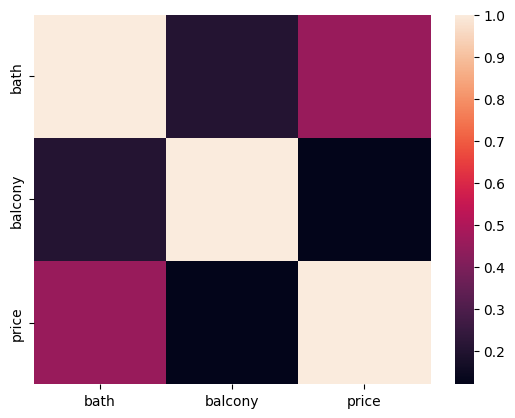

In [ ]:
corr=df.select_dtypes("number").corr()
sns.heatmap(corr)

In [ ]:
df.isnull().sum()

,0
area_type,0
availability,0
location,1
size,16
society,5502
total_sqft,0
bath,73
balcony,609
price,0


In [ ]:
df1=df.drop(columns=['area_type','society','balcony','availability'])

In [ ]:
df1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13320 entries, 0 to 13319
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   location    13319 non-null  object 
 1   size        13304 non-null  object 
 2   total_sqft  13320 non-null  object 
 3   bath        13247 non-null  float64
 4   price       13320 non-null  float64
dtypes: float64(2), object(3)
memory usage: 520.4+ KB


In [ ]:
df1.dropna(inplace=True)

In [ ]:
df1.isnull().sum()

,0
location,0
size,0
total_sqft,0
bath,0
price,0


In [ ]:

df1['size'].unique()

array(['2 BHK', '4 Bedroom', '3 BHK', '4 BHK', '6 Bedroom', '3 Bedroom',
       '1 BHK', '1 RK', '1 Bedroom', '8 Bedroom', '2 Bedroom',
       '7 Bedroom', '5 BHK', '7 BHK', '6 BHK', '5 Bedroom', '11 BHK',
       '9 BHK', '9 Bedroom', '27 BHK', '10 Bedroom', '11 Bedroom',
       '10 BHK', '19 BHK', '16 BHK', '43 Bedroom', '14 BHK', '8 BHK',
       '12 Bedroom', '13 BHK', '18 Bedroom'], dtype=object)

In [ ]:
df1['bedrooms']=df1['size'].apply(lambda x: int(x.split(" ")[0]))

In [ ]:
df1.info()

<class 'pandas.core.frame.DataFrame'>
Index: 13246 entries, 0 to 13319
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   location    13246 non-null  object 
 1   size        13246 non-null  object 
 2   total_sqft  13246 non-null  object 
 3   bath        13246 non-null  float64
 4   price       13246 non-null  float64
 5   bedrooms    13246 non-null  int64  
dtypes: float64(2), int64(1), object(3)
memory usage: 724.4+ KB


In [ ]:
df1.head()

,location,size,total_sqft,bath,price,bedrooms
0,Electronic City Phase II,2 BHK,1056,2.0,39.07,2
1,Chikka Tirupathi,4 Bedroom,2600,5.0,120.00,4
2,Uttarahalli,3 BHK,1440,2.0,62.00,3
3,Lingadheeranahalli,3 BHK,1521,3.0,95.00,3
4,Kothanur,2 BHK,1200,2.0,51.00,2


In [ ]:
df1=df1.drop(columns='size')

KeyError: "['size'] not found in axis"

In [ ]:
df1['bedrooms'].unique()

array([ 2,  4,  3,  6,  1,  8,  7,  5, 11,  9, 27, 10, 19, 16, 43, 14, 12,
       13, 18])

In [ ]:
df1[df1.bedrooms>20]

,location,total_sqft,bath,price,bedrooms
1718,2Electronic City Phase II,8000,27.0,230.0,27
4684,Munnekollal,2400,40.0,660.0,43


In [ ]:
df1['total_sqft'].unique()

array(['1056', '2600', '1440', ..., '1133 - 1384', '774', '4689'],
      dtype=object)

In [ ]:
def is_float(x):
    try:
        float(x)
        return True
    except:
        return False

In [ ]:
df1[~df1['total_sqft'].apply(is_float)].head(10)

,location,total_sqft,bath,price,bedrooms
30,Yelahanka,2100 - 2850,4.0,186.000,4
122,Hebbal,3067 - 8156,4.0,477.000,4
137,8th Phase JP Nagar,1042 - 1105,2.0,54.005,2
165,Sarjapur,1145 - 1340,2.0,43.490,2
188,KR Puram,1015 - 1540,2.0,56.800,2
410,Kengeri,34.46Sq. Meter,1.0,18.500,1
549,Hennur Road,1195 - 1440,2.0,63.770,2
648,Arekere,4125Perch,9.0,265.000,9
661,Yelahanka,1120 - 1145,2.0,48.130,2
672,Bettahalsoor,3090 - 5002,4.0,445.000,4


In [ ]:
def convert_sqft_to_num(x):
    if isinstance(x,float):
        return x
    tokens=str(x).split('-')
    if len(tokens)==2:
        return (float(tokens[0])+float(tokens[1]))/2
    try:
        return float(x)
    except:
        return None

In [ ]:
df4=df1.copy()
df4['total_sqft']=df4['total_sqft'].apply(convert_sqft_to_num)
df4.dropna(inplace=True)
df4.info()

<class 'pandas.core.frame.DataFrame'>
Index: 13200 entries, 0 to 13319
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   location    13200 non-null  object 
 1   total_sqft  13200 non-null  float64
 2   bath        13200 non-null  float64
 3   price       13200 non-null  float64
 4   bedrooms    13200 non-null  int64  
dtypes: float64(3), int64(1), object(1)
memory usage: 618.8+ KB


Applying the `convert_sqft_to_num` function to the `total_sqft` column to transform its values into a numerical format, handling ranges by taking their average and setting unparseable strings to `None` (which Pandas converts to `NaN`).

In [ ]:
df1['total_sqft'] = df1['total_sqft'].apply(convert_sqft_to_num)

Now, let's check for any `NaN` values that resulted from the conversion process in the `total_sqft` column.

In [ ]:
df1.isnull().sum()

Since we have a relatively small number of `NaN`s in `total_sqft` after conversion, I'll drop these rows to ensure our dataset contains only valid numerical values for this column.

In [ ]:
df1.dropna(inplace=True)

Finally, let's verify the DataFrame's information to confirm that `total_sqft` is now a numerical type and that there are no more null values.

In [ ]:
df1.info()

<class 'pandas.core.frame.DataFrame'>
Index: 13246 entries, 0 to 13319
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   location    13246 non-null  object 
 1   total_sqft  13246 non-null  object 
 2   bath        13246 non-null  float64
 3   price       13246 non-null  float64
 4   bedrooms    13246 non-null  int64  
dtypes: float64(2), int64(1), object(2)
memory usage: 620.9+ KB


{'whiskers': [<matplotlib.lines.Line2D at 0x79e08f4aaab0>,
 'caps': [<matplotlib.lines.Line2D at 0x79e08f2d8b90>,
 'boxes': [<matplotlib.lines.Line2D at 0x79e08f2db470>],
 'medians': [<matplotlib.lines.Line2D at 0x79e08f2d91c0>],
 'fliers': [<matplotlib.lines.Line2D at 0x79e08f2d93d0>],
 'means': []}

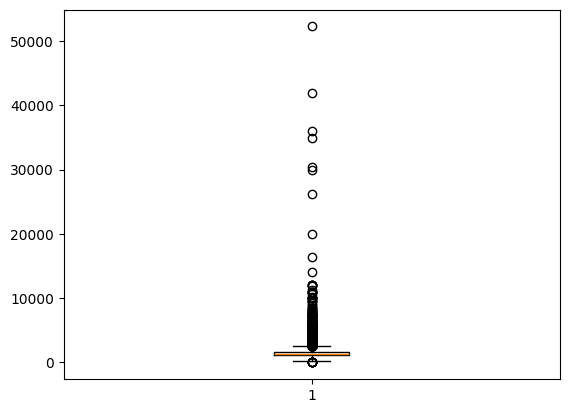

In [ ]:
plt.boxplot(df4['total_sqft'])

In [ ]:
low,high=df4['total_sqft'].quantile([0.1,0.9])
mask_area=df4['total_sqft'].between(low,high)
df4=df4[mask_area]

{'whiskers': [<matplotlib.lines.Line2D at 0x79e08f495dc0>,
 'caps': [<matplotlib.lines.Line2D at 0x79e08f495f70>,
 'boxes': [<matplotlib.lines.Line2D at 0x79e08f494e00>],
 'medians': [<matplotlib.lines.Line2D at 0x79e08f4974d0>],
 'fliers': [<matplotlib.lines.Line2D at 0x79e08f496660>],
 'means': []}

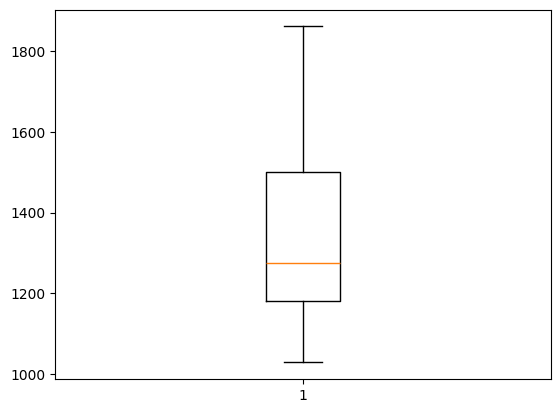

In [ ]:
plt.boxplot(df4['total_sqft'])